In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
df = pd.read_csv('../Housing.csv')

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split X and Y
X = df.drop('price', axis=1)
Y = df['price']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Model
regModel = MLPRegressor(hidden_layer_sizes=(256,128,64,32),
                        activation='relu',
                        solver='sgd',
                        max_iter=1000,
                        random_state=42)

regModel.fit(X_train, Y_train)

Y_pred = regModel.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

# K-Fold Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(regModel, X_scaled, Y, cv=kf, scoring='r2')

print("Cross-Validation R2 Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())

MSE: 4.1603116850110054e+29
R2 Score: -8.230792099500909e+16
Cross-Validation R2 Scores: [-2.24209751e+16 -7.19489150e+92 -4.85623082e+31 -1.15816089e+17
 -3.54232585e+16]
Average R2 Score: -1.4389782992329266e+92


In [14]:
iris = pd.read_csv("../Iris.csv")

X = iris.drop('Species', axis=1)
Y = iris['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


===== Fold 1 =====


c:\Tools\miniconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 1.0
Test Accuracy: 1.0


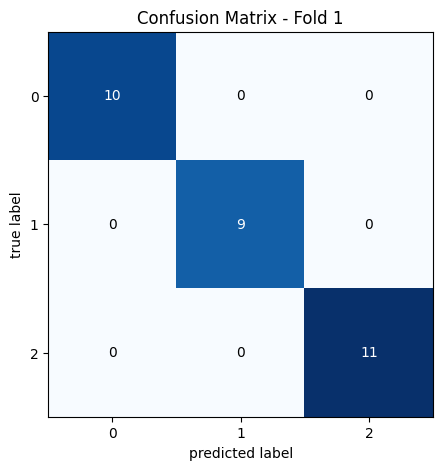


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


===== Fold 2 =====
Train Accuracy: 1.0
Test Accuracy: 1.0


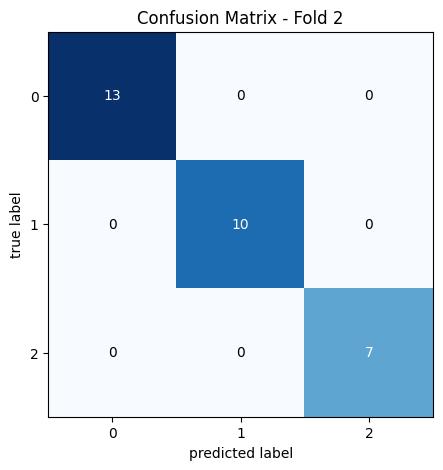


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00         7

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


===== Fold 3 =====
Train Accuracy: 1.0
Test Accuracy: 1.0


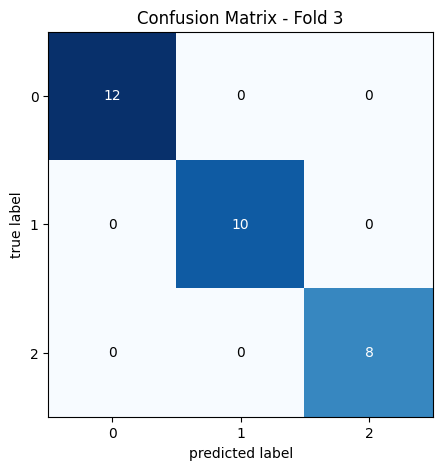


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00         8

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


===== Fold 4 =====
Train Accuracy: 1.0
Test Accuracy: 1.0


c:\Tools\miniconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


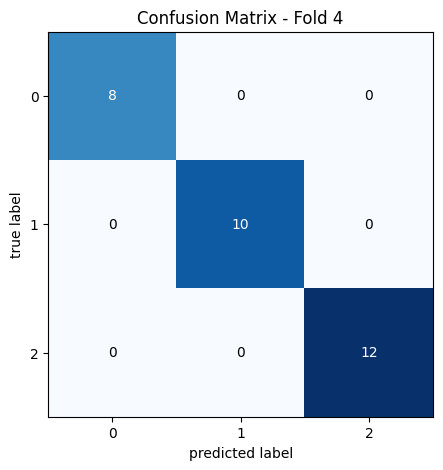


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        12

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


===== Fold 5 =====
Train Accuracy: 1.0
Test Accuracy: 0.9666666666666667


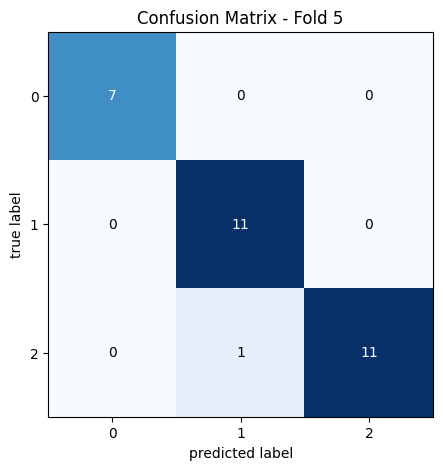


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Average Train Accuracy: 1.0
Average Test Accuracy: 0.9933333333333334


In [15]:
# K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_acc_list = []
test_acc_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X_scaled)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    # Model
    clsModel = MLPClassifier(hidden_layer_sizes=(34,22),
                             activation='relu',
                             solver='sgd',
                             max_iter=1000,
                             random_state=42)

    
    clsModel.fit(X_train, Y_train)

    Y_trainPred = clsModel.predict(X_train)
    Y_testPred = clsModel.predict(X_test)

   
    train_acc = accuracy_score(Y_train, Y_trainPred)
    test_acc = accuracy_score(Y_test, Y_testPred)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)


    cm = confusion_matrix(Y_test, Y_testPred)
    
    plot_confusion_matrix(conf_mat=cm, figsize=(5,5))
    plt.title(f"Confusion Matrix - Fold {fold+1}")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(Y_test, Y_testPred))

# Average Accuracy
print("\n==============================")
print("Average Train Accuracy:", np.mean(train_acc_list))
print("Average Test Accuracy:", np.mean(test_acc_list))